LOAD DATA

In [23]:
import pandas as pd

respiban = pd.read_csv(
    "../../data/raw/WESAD/S2/S2_respiban.txt",
    sep="\t",
    comment="#",
    header=None
)

print(respiban.head())
print(respiban.shape)
print(respiban.head(3))


   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN
3   3   0  30374  14701  32569  29553  37405  32341  31671  31076 NaN
4   4   0  30103  14684  32794  29561  37409  32342  31681  31365 NaN
(4442067, 11)
   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN


After Filtering we see a huge jump in amplitude- This is due to constant/DC offset.
The respiban data has raw adc counts(not converted in its si units) and hence a constant jump is noticed

(4442067,)


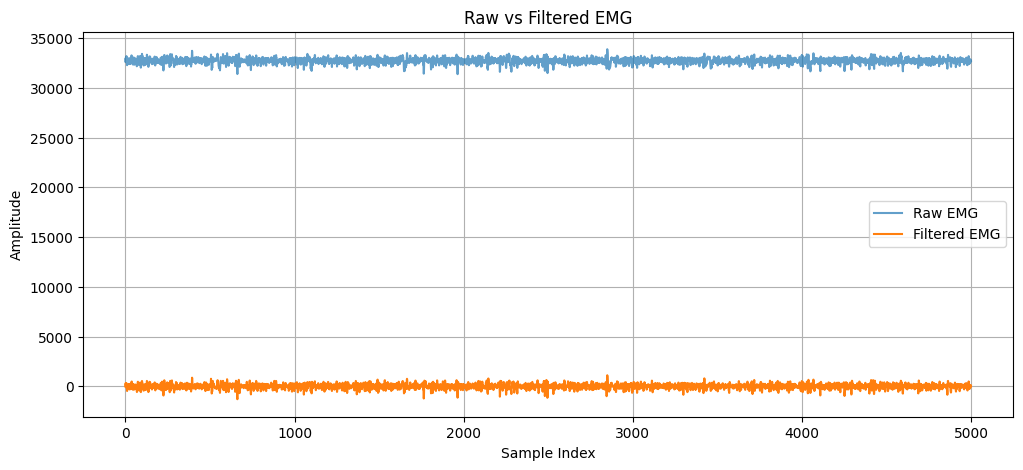

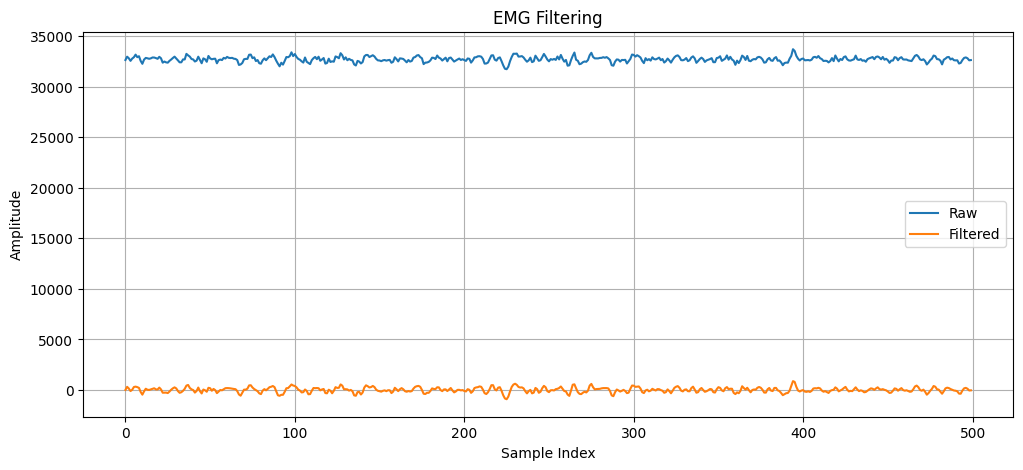

Raw mean: 32715.290662432602
Filtered mean: 0.00026327057552914324
Raw min: 23703 Raw max: 39343
Filtered min: -7492.79703272306 Filtered max: 5477.897516819406


In [24]:
from scipy.signal import butter, filtfilt
import numpy as np

emg = respiban.iloc[:, 4].values   # or respiban[3].values
fs = 700

lowcut = 20
highcut = 250

nyquist = fs / 2

b, a = butter(
    4,
    [lowcut/nyquist, highcut/nyquist],
    btype='band'
)

emg_filtered = filtfilt(b, a, emg)

print(emg.shape)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(emg[:5000], label="Raw EMG", alpha=0.7)
plt.plot(emg_filtered[:5000], label="Filtered EMG")

plt.title("Raw vs Filtered EMG")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()
plt.figure(figsize=(12,5))

plt.plot(emg[:500], label='Raw')
plt.plot(emg_filtered[:500], label='Filtered')

plt.title('EMG Filtering')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.show()
print("Raw mean:", np.mean(emg))
print("Filtered mean:", np.mean(emg_filtered))

print("Raw min:", np.min(emg), "Raw max:", np.max(emg))
print("Filtered min:", np.min(emg_filtered), "Filtered max:", np.max(emg_filtered))

Plotting the graph after removing the dc offset

Original Mean: 32715.290662432602
Centered Mean: -6.433408861702437e-13


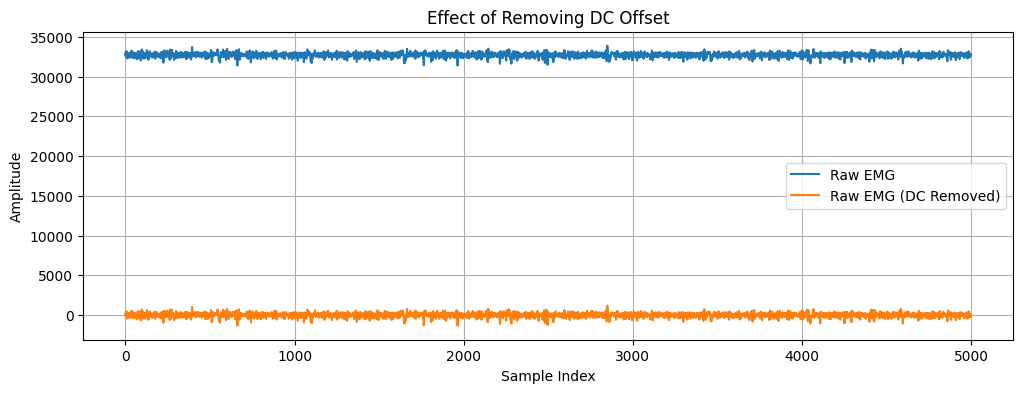

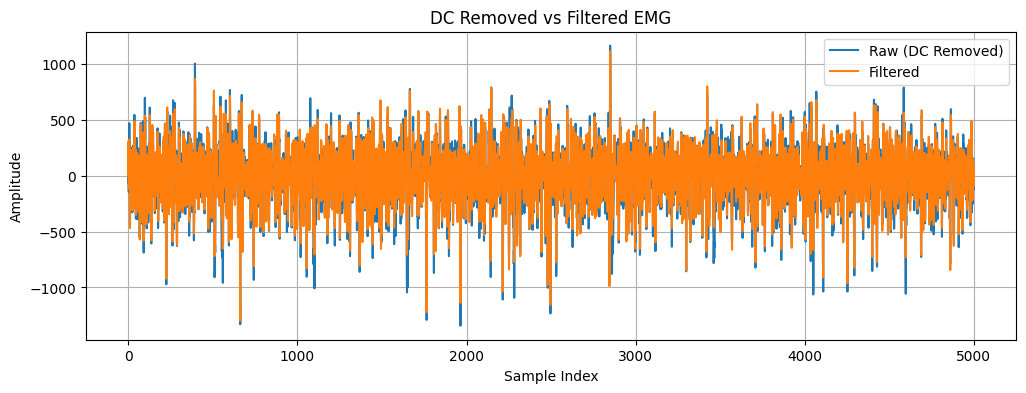

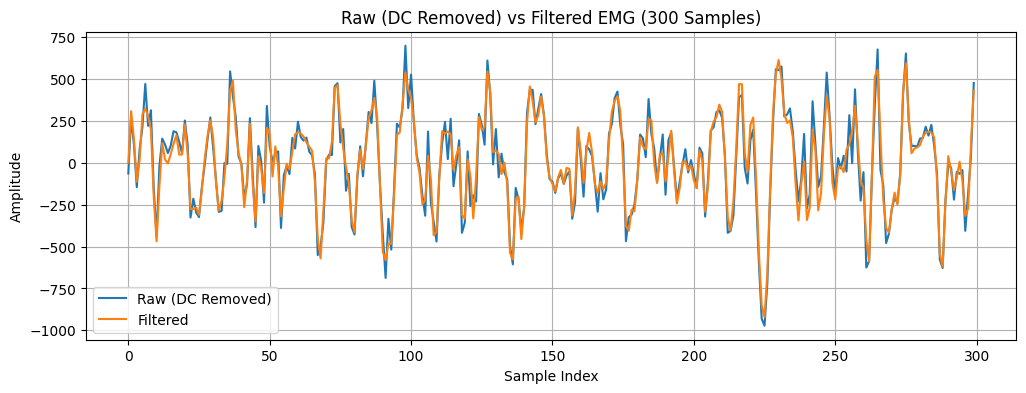

In [25]:
import numpy as np

emg_centered = emg - np.mean(emg)                       #dc offset removed
print("Original Mean:", np.mean(emg))
print("Centered Mean:", np.mean(emg_centered))

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(emg[:5000], label="Raw EMG")
plt.plot(emg_centered[:5000], label="Raw EMG (DC Removed)")

plt.title("Effect of Removing DC Offset")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))

plt.plot(emg_centered[:5000], label="Raw (DC Removed)")
plt.plot(emg_filtered[:5000], label="Filtered")

plt.title("DC Removed vs Filtered EMG")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt

# Number of samples to display
n_samples = 300

plt.figure(figsize=(12,4))

plt.plot(emg_centered[:n_samples], label="Raw (DC Removed)", linewidth=1.5)
plt.plot(emg_filtered[:n_samples], label="Filtered", linewidth=1.5)

plt.title(f"Raw (DC Removed) vs Filtered EMG ({n_samples} Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
import numpy as np
import pandas as pd



emg_centered = emg - np.mean(emg)
# Mean
emg_mean_raw = np.mean(emg)
emg_mean_filtered = np.mean(emg_filtered)
emg_mean_centered = np.mean(emg_centered)
# Standard deviation
emg_std_raw = np.std(emg)
emg_std_filtered = np.std(emg_filtered)
emg_std_centered =np.std(emg_centered)

# Spikes
emg_z_raw = np.abs((emg - emg_mean_raw) / emg_std_raw)
emg_z_filtered = np.abs((emg_filtered - emg_mean_filtered) / emg_std_filtered)
emg_z_centered = np.abs(
    (emg_centered - emg_mean_centered) / emg_std_centered
)

emg_spikes_raw = np.sum(emg_z_raw > 3)
emg_spikes_filtered = np.sum(emg_z_filtered > 3)
emg_spikes_centered = np.sum(emg_z_centered > 3)

# Noise estimate
emg_noise_raw = np.std(np.diff(emg))
emg_noise_filtered = np.std(np.diff(emg_filtered))
emg_noise_centered = np.std(np.diff(emg_centered))
# Drift estimate
window = 7000

emg_drift_raw = np.std(
    np.convolve(emg, np.ones(window)/window, mode='same')
)

emg_drift_filtered = np.std(
    np.convolve(emg_filtered, np.ones(window)/window, mode='same')
)
emg_drift_centered = np.std(
    np.convolve(emg_centered,
                np.ones(window)/window,
                mode='same')
)

results = pd.DataFrame({
    "Metric": ["Mean","Std","Spikes (>3σ)","Noise Estimate","Drift Estimate"],
    "Raw": [
        emg_mean_raw,
        emg_std_raw,
        emg_spikes_raw,
        emg_noise_raw,
        emg_drift_raw
    ],
    "Filtered": [
        emg_mean_filtered,
        emg_std_filtered,
        emg_spikes_filtered,
        emg_noise_filtered,
        emg_drift_filtered
    ],

    "Centered(DC offset removed)":[
        emg_mean_centered,
        emg_std_centered,
        emg_spikes_centered,
        emg_noise_centered,
        emg_drift_centered
    ]
})

print(results)

           Metric           Raw      Filtered  Centered(DC offset removed)
0            Mean  32715.290662      0.000263                -6.433409e-13
1             Std    253.541724    220.305824                 2.535417e+02
2    Spikes (>3σ)  68188.000000  62161.000000                 6.818800e+04
3  Noise Estimate    240.252435    183.314860                 2.402524e+02
4  Drift Estimate    374.674477      0.102448                 4.498918e+00


| **Metric**         | **DC Removed** | **Filtered** | **Improvement (%)** | **Interpretation**                                                                        |
| ------------------ | -------------: | -----------: | ------------------: | ----------------------------------------------------------------------------------------- |
| Mean               |             ≈0 |           ≈0 |             **≈0%** | Both signals are centered around zero.                                                    |
| Standard Deviation |         253.54 |       220.31 |          **13.11%** | Filtering reduces unwanted signal variations while preserving the EMG waveform.           |
| Spike Count        |          68188 |        62161 |           **8.84%** | High-amplitude artifacts and spikes are reduced after filtering.                          |
| Noise Estimate     |         240.25 |       183.31 |          **23.70%** | Random noise is reduced, producing a cleaner signal.                                      |
| Drift Estimate     |           4.50 |        0.102 |          **97.72%** | The filter effectively removes the remaining slow baseline drift after DC offset removal. |


| **Aspect**         | **Conclusion**                                                                                                                                                            |
| ------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Mean               | Both the DC-offset removed and filtered signals are centered around zero, indicating successful baseline centering.                                                       |
| Signal Variability | The filter reduces overall signal variability by **13.11%**, indicating suppression of unwanted fluctuations.                                                             |
| Spike Reduction    | The number of extreme spikes decreases by **8.84%**, showing effective reduction of motion artifacts and noise.                                                           |
| Noise Reduction    | The noise estimate decreases by **23.70%**, resulting in a cleaner EMG signal.                                                                                            |
| Baseline Drift     | The remaining baseline drift is reduced by **97.72%**, demonstrating that the bandpass filter removes slow-varying baseline fluctuations beyond simple DC offset removal. |
